going to get looking at some data

In [1]:
import pandas as pd
import numpy as np

big_data_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\2015-2025jSPXoptions.csv"

big_data = pd.read_csv(big_data_filepath)



In [2]:
# Inspect data structure
print("Dataset shape:", big_data.shape)
print("\nColumn names and types:")
print(big_data.info())
print("\nFirst few rows:")
print(big_data.head(5))
print("\nBasic statistics:")
print(big_data.describe())
print("\nData types:")
print(big_data.dtypes)
print("\nMissing values:")
print(big_data.isnull().sum())

Dataset shape: (42225530, 23)

Column names and types:
<class 'pandas.DataFrame'>
RangeIndex: 42225530 entries, 0 to 42225529
Data columns (total 23 columns):
 #   Column            Dtype  
---  ------            -----  
 0   secid             int64  
 1   date              str    
 2   symbol            str    
 3   exdate            str    
 4   cp_flag           str    
 5   strike_price      int64  
 6   best_bid          float64
 7   best_offer        float64
 8   volume            int64  
 9   open_interest     int64  
 10  impl_volatility   float64
 11  delta             float64
 12  gamma             float64
 13  vega              float64
 14  theta             float64
 15  optionid          int64  
 16  forward_price     float64
 17  expiry_indicator  str    
 18  index_flag        int64  
 19  issue_type        str    
 20  industry_group    float64
 21  issuer            str    
 22  exercise_style    str    
dtypes: float64(9), int64(6), str(8)
memory usage: 7.2 GB
None

Fi

In [3]:
columns_to_keep = ["secid", "date", "exdate", "cp_flag", "strike_price", "best_bid", "best_offer",
                    "optionid", "exercise_style", "delta", "vega", "gamma", "impl_volatility"]

filtered_data = big_data[columns_to_keep]
# Rename strike_price to K and divide by 1000
filtered_data = filtered_data.rename(columns={'strike_price': 'K'})
filtered_data['K'] = filtered_data['K'] / 1000

print(filtered_data.head(5))

#about equal number of calls and puts
#only european options

    secid        date      exdate cp_flag       K  best_bid  best_offer  \
0  108105  02/01/2015  17/01/2015       C   100.0    1956.4      1959.6   
1  108105  02/01/2015  17/01/2015       C  1000.0    1056.7      1059.9   
2  108105  02/01/2015  17/01/2015       C  1025.0    1031.7      1034.9   
3  108105  02/01/2015  17/01/2015       C  1050.0    1006.7      1009.8   
4  108105  02/01/2015  17/01/2015       C  1075.0     981.7       984.8   

    optionid exercise_style     delta      vega     gamma  impl_volatility  
0  101234071              E       NaN       NaN       NaN              NaN  
1  101234072              E  0.999103  1.179546  0.000006         1.222229  
2  101234073              E  0.999083  1.204660  0.000006         1.181493  
3  101234074              E  0.999391  0.808892  0.000005         1.092237  
4  101234075              E  0.999382  0.820990  0.000005         1.054338  


In [4]:
# Convert date column to datetime format (dd/mm/yyyy)
filtered_data['date'] = pd.to_datetime(filtered_data['date'], format='%d/%m/%Y')
filtered_data['exdate'] = pd.to_datetime(filtered_data['exdate'], format='%d/%m/%Y')

# Filter data to only include dates between 02/16/2015 and 01/07/2021
cutoff_date_start = pd.to_datetime('2015-10-16')
cutoff_date_end = pd.to_datetime('2021-07-01')
filtered_data = filtered_data[(filtered_data['date'] >= cutoff_date_start) & (filtered_data['date'] < cutoff_date_end)]

print(f"Dataset shape after date filter: {filtered_data.shape}")
print(f"\nDate range: {filtered_data['date'].min()} to {filtered_data['date'].max()}")
print(f"\nFirst few rows:")
print(filtered_data.head())

Dataset shape after date filter: (18194288, 13)

Date range: 2015-10-16 00:00:00 to 2021-06-30 00:00:00

First few rows:
          secid       date     exdate cp_flag       K  best_bid  best_offer  \
1561744  108105 2015-10-16 2015-11-20       C  1000.0    1025.3      1030.0   
1561745  108105 2015-10-16 2015-11-20       C  1025.0    1000.4      1005.0   
1561746  108105 2015-10-16 2015-11-20       C  1050.0     975.4       980.0   
1561747  108105 2015-10-16 2015-11-20       C  1075.0     950.4       955.1   
1561748  108105 2015-10-16 2015-11-20       C  1100.0     925.4       930.1   

          optionid exercise_style     delta      vega     gamma  \
1561744  108485570              E  0.996078  2.218131  0.000007   
1561745  108485571              E  0.995777  2.784215  0.000009   
1561746  108485572              E  0.995758  2.818352  0.000010   
1561747  108485573              E  0.995439  3.404782  0.000012   
1561748  108485574              E  0.995409  3.459122  0.000013   

 

In [5]:
# Load SPX price data
spx_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\S&P 500 Historical Data 2015-2022.csv"  # Update filename if needed

spx_data = pd.read_csv(spx_filepath)

# Convert SPX date column to datetime format (mm/dd/yyyy)
spx_data['Date'] = pd.to_datetime(spx_data['Date'], format='%m/%d/%Y')

# Convert both date columns to date only (removing time component) for proper merging
# First ensure filtered_data['date'] is datetime before converting
if not pd.api.types.is_datetime64_any_dtype(filtered_data['date']):
    filtered_data['date'] = pd.to_datetime(filtered_data['date'])
    
filtered_data['date'] = filtered_data['date'].dt.date
filtered_data['exdate'] = filtered_data['exdate'].dt.date
spx_data['Date'] = spx_data['Date'].dt.date

print(spx_data.head())

# Merge filtered_data with spx_data on date columns
filtered_data = filtered_data.merge(spx_data[['Date', 'Price']], 
                                    left_on='date', 
                                    right_on='Date', 
                                    how='left')

# Rename 'Price' to 'S' and drop the duplicate 'Date' column
filtered_data = filtered_data.rename(columns={'Price': 'S'})
filtered_data = filtered_data.drop(columns=['Date'])



# Remove duplicate S columns, keeping only the first one
s_columns = [col for col in filtered_data.columns if col == 'S']
if len(s_columns) > 1:
    # Get all columns and remove duplicates
    filtered_data = filtered_data.loc[:, ~filtered_data.columns.duplicated(keep='first')]
    print("Removed duplicate columns")

print("Merge complete!")
print(f"Filtered data shape: {filtered_data.shape}")
print(f"\nFirst few rows:")
print(filtered_data.head())

         Date    Price      Open      High       Low  Vol. Change %
0  2025-10-03  6715.79  6,722.14  6,750.87  6,705.67   NaN    0.01%
1  2025-10-02  6715.35  6,731.31  6,731.94  6,693.23   NaN    0.06%
2  2025-10-01  6711.20  6,664.92  6,718.48  6,656.20   NaN    0.34%
3  2025-09-30  6688.46  6,656.19  6,691.25  6,641.00   NaN    0.41%
4  2025-09-29  6661.21  6,661.58  6,677.31  6,644.49   NaN    0.26%
Merge complete!
Filtered data shape: (18194288, 14)

First few rows:
    secid        date      exdate cp_flag       K  best_bid  best_offer  \
0  108105  2015-10-16  2015-11-20       C  1000.0    1025.3      1030.0   
1  108105  2015-10-16  2015-11-20       C  1025.0    1000.4      1005.0   
2  108105  2015-10-16  2015-11-20       C  1050.0     975.4       980.0   
3  108105  2015-10-16  2015-11-20       C  1075.0     950.4       955.1   
4  108105  2015-10-16  2015-11-20       C  1100.0     925.4       930.1   

    optionid exercise_style     delta      vega     gamma  impl_volatili

In [6]:
vix_filepath = r"C:\Users\samib\OneDrive - Imperial College London\Imperial\Education\Year 4\Masters Project\Code\MastersProject\Data\Full_VIX_History.csv"  # Update filename if needed

vix_data = pd.read_csv(vix_filepath)

# Convert VIX date column to datetime format (mm/dd/yyyy)
vix_data['DATE'] = pd.to_datetime(vix_data['DATE'], format='%m/%d/%Y')

# Convert DATE to date only (removing time component) to match filtered_data['date']
vix_data['DATE'] = vix_data['DATE'].dt.date


print(vix_data.head())

# Merge filtered_data with vix_data on date columns
filtered_data = filtered_data.merge(vix_data[['DATE', 'CLOSE']], 
                                    left_on='date', 
                                    right_on='DATE', 
                                    how='left')

# Rename 'CLOSE' to 'sigma' and drop the duplicate 'DATE' column
filtered_data = filtered_data.rename(columns={'CLOSE': 'sigma'})
filtered_data = filtered_data.drop(columns=['DATE'])

#turn sigma into percentage
filtered_data['sigma'] = filtered_data['sigma'] / 100

print("Merge complete!")
print(f"Filtered data shape: {filtered_data.shape}")
print(f"\nFirst few rows:")
print(filtered_data.head())

         DATE   OPEN   HIGH    LOW  CLOSE
0  1990-01-02  17.24  17.24  17.24  17.24
1  1990-01-03  18.19  18.19  18.19  18.19
2  1990-01-04  19.22  19.22  19.22  19.22
3  1990-01-05  20.11  20.11  20.11  20.11
4  1990-01-08  20.26  20.26  20.26  20.26
Merge complete!
Filtered data shape: (18194288, 15)

First few rows:
    secid        date      exdate cp_flag       K  best_bid  best_offer  \
0  108105  2015-10-16  2015-11-20       C  1000.0    1025.3      1030.0   
1  108105  2015-10-16  2015-11-20       C  1025.0    1000.4      1005.0   
2  108105  2015-10-16  2015-11-20       C  1050.0     975.4       980.0   
3  108105  2015-10-16  2015-11-20       C  1075.0     950.4       955.1   
4  108105  2015-10-16  2015-11-20       C  1100.0     925.4       930.1   

    optionid exercise_style     delta      vega     gamma  impl_volatility  \
0  108485570              E  0.996078  2.218131  0.000007         0.785110   
1  108485571              E  0.995777  2.784215  0.000009         0.7771

In [7]:
#want to add interest rates now!!!
interestrate_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\yield-curve-rates-2015-2025.csv"  # Update filename if needed

ir_data = pd.read_csv(interestrate_filepath)

def parse_mixed_date(date_str):
    try:
        # Try mm/dd/yyyy format first
        return pd.to_datetime(date_str, format='%m/%d/%Y')
    except:
        try:
            # Fall back to mm/dd/yy format
            return pd.to_datetime(date_str, format='%m/%d/%y')
        except:
            print(f"Unrecognized date format: {date_str}")

ir_data['Date'] = ir_data['Date'].apply(parse_mixed_date).dt.date

# Rename columns
ir_data = ir_data.rename(columns={
    '1 Mo': 'r 1 Mo',
    '3 Mo': 'r 3 Mo',
    '6 Mo': 'r 6 Mo'
})

# Merge interest rate data with filtered_data
filtered_data = filtered_data.merge(ir_data[['Date', 'r 1 Mo', 'r 3 Mo', 'r 6 Mo']], 
                                    left_on='date', 
                                    right_on='Date', 
                                    how='left')

# Drop the duplicate Date column
filtered_data = filtered_data.drop(columns=['Date'])

rate_cols = ['r 1 Mo', 'r 3 Mo', 'r 6 Mo']

# strip weird characters and coerce to numbers
for c in rate_cols:
    filtered_data[c] = (
        filtered_data[c]
        .astype(str)
        .str.replace('%','', regex=False)
        .str.replace(',','', regex=False)
        .str.strip()
    )
    filtered_data[c] = pd.to_numeric(filtered_data[c], errors='coerce')

# now divide by 100 (if the values are in percent units like 5.25)
filtered_data[rate_cols] = filtered_data[rate_cols] / 100


print("Interest rate merge complete!")
print(f"Filtered data shape: {filtered_data.shape}")
print(f"Columns: {list(filtered_data.columns)}")
print(f"\nFirst few rows:")
print(filtered_data.head())



Interest rate merge complete!
Filtered data shape: (18194288, 18)
Columns: ['secid', 'date', 'exdate', 'cp_flag', 'K', 'best_bid', 'best_offer', 'optionid', 'exercise_style', 'delta', 'vega', 'gamma', 'impl_volatility', 'S', 'sigma', 'r 1 Mo', 'r 3 Mo', 'r 6 Mo']

First few rows:
    secid        date      exdate cp_flag       K  best_bid  best_offer  \
0  108105  2015-10-16  2015-11-20       C  1000.0    1025.3      1030.0   
1  108105  2015-10-16  2015-11-20       C  1025.0    1000.4      1005.0   
2  108105  2015-10-16  2015-11-20       C  1050.0     975.4       980.0   
3  108105  2015-10-16  2015-11-20       C  1075.0     950.4       955.1   
4  108105  2015-10-16  2015-11-20       C  1100.0     925.4       930.1   

    optionid exercise_style     delta      vega     gamma  impl_volatility  \
0  108485570              E  0.996078  2.218131  0.000007         0.785110   
1  108485571              E  0.995777  2.784215  0.000009         0.777109   
2  108485572              E  0.995

In [8]:
# Convert S and K to numeric types
filtered_data['S'] = pd.to_numeric(filtered_data['S'], errors='coerce')
filtered_data['K'] = pd.to_numeric(filtered_data['K'], errors='coerce')

# Convert date columns back to datetime for arithmetic operations
filtered_data['date'] = pd.to_datetime(filtered_data['date'])
filtered_data['exdate'] = pd.to_datetime(filtered_data['exdate'])

# Calculate new columns
# mid: midpoint of bid-ask spread
filtered_data['mid'] = (filtered_data['best_bid'] + filtered_data['best_offer']) / 2

# T: time to expiration in years
filtered_data['T'] = (filtered_data['exdate'] - filtered_data['date']).dt.days / 365.0

# Log-moneyness: log(S/K)
filtered_data['log_moneyness'] = np.log(filtered_data['S'] / filtered_data['K'])

# Remove duplicate S columns, keeping only the first one
s_columns = [col for col in filtered_data.columns if col == 'S']
if len(s_columns) > 1:
    # Get all columns and remove duplicates
    filtered_data = filtered_data.loc[:, ~filtered_data.columns.duplicated(keep='first')]
    print("Removed duplicate columns")

# Debug: Check cp_flag values before mapping
print("cp_flag values before mapping:")
print(filtered_data['cp_flag'].unique())
print(f"cp_flag data type: {filtered_data['cp_flag'].dtype}")
print(f"cp_flag null count: {filtered_data['cp_flag'].isnull().sum()}")

filtered_data["cp_flag"] = filtered_data["cp_flag"].map({"C": 1, "P": 0})

print("\nNew columns created!")
print(f"Filtered data shape: {filtered_data.shape}")
print(f"\nColumns: {list(filtered_data.columns)}")
print(f"\nFirst few rows:")
print(filtered_data.head())
print(filtered_data.tail())

# Print unique cp_flag values
print("\nUnique cp_flag values in training data:", filtered_data['cp_flag'].unique())
print("Unique cp_flag values in test data:", filtered_data['cp_flag'].unique())





cp_flag values before mapping:
<StringArray>
['C', 'P']
Length: 2, dtype: str
cp_flag data type: str
cp_flag null count: 0

New columns created!
Filtered data shape: (18194288, 21)

Columns: ['secid', 'date', 'exdate', 'cp_flag', 'K', 'best_bid', 'best_offer', 'optionid', 'exercise_style', 'delta', 'vega', 'gamma', 'impl_volatility', 'S', 'sigma', 'r 1 Mo', 'r 3 Mo', 'r 6 Mo', 'mid', 'T', 'log_moneyness']

First few rows:
    secid       date     exdate  cp_flag       K  best_bid  best_offer  \
0  108105 2015-10-16 2015-11-20        1  1000.0    1025.3      1030.0   
1  108105 2015-10-16 2015-11-20        1  1025.0    1000.4      1005.0   
2  108105 2015-10-16 2015-11-20        1  1050.0     975.4       980.0   
3  108105 2015-10-16 2015-11-20        1  1075.0     950.4       955.1   
4  108105 2015-10-16 2015-11-20        1  1100.0     925.4       930.1   

    optionid exercise_style     delta  ...     gamma  impl_volatility       S  \
0  108485570              E  0.996078  ...  0.00

In [9]:
#putting in Black scholes price for feature
from math import erf, sqrt

def norm_cdf(x):
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))

def bs_price_row(S, K, T, r, sigma, cp_flag):
    # Basic guards
    if not np.isfinite(S) or not np.isfinite(K) or not np.isfinite(T) or not np.isfinite(r) or not np.isfinite(sigma):
        return np.nan
    if S <= 0 or K <= 0 or T <= 0 or sigma <= 0:
        return np.nan

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if cp_flag == 1:  # Call
        return S * norm_cdf(d1) - K * np.exp(-r * T) * norm_cdf(d2)
    else:            # Put
        return K * np.exp(-r * T) * norm_cdf(-d2) - S * norm_cdf(-d1)

# Choose your rate column
r_col = "r 3 Mo"

# Ensure rate is decimal (uncomment if your rates are in percent units)
# filtered_data[r_col] = filtered_data[r_col] / 100.0

# Compute BS price
filtered_data["bs_price"] = filtered_data.apply(
    lambda row: bs_price_row(row["S"], row["K"], row["T"], row[r_col], row["sigma"], row["cp_flag"]),
    axis=1
)

print("Added bs_price column.")
print(filtered_data[["S","K","T",r_col,"sigma","cp_flag","mid","bs_price", 'delta', "vega", "gamma", "impl_volatility"]].head())

Added bs_price column.
        S       K        T  r 3 Mo   sigma  cp_flag      mid     bs_price  \
0  2033.1  1000.0  0.09589  0.0001  0.1505        1  1027.65  1033.109589   
1  2033.1  1025.0  0.09589  0.0001  0.1505        1  1002.70  1008.109829   
2  2033.1  1050.0  0.09589  0.0001  0.1505        1   977.70   983.110068   
3  2033.1  1075.0  0.09589  0.0001  0.1505        1   952.75   958.110308   
4  2033.1  1100.0  0.09589  0.0001  0.1505        1   927.75   933.110548   

      delta      vega     gamma  impl_volatility  
0  0.996078  2.218131  0.000007         0.785110  
1  0.995777  2.784215  0.000009         0.777109  
2  0.995758  2.818352  0.000010         0.749627  
3  0.995439  3.404782  0.000012         0.738809  
4  0.995409  3.459122  0.000013         0.712394  


In [10]:
# Sort entire dataset by contract and date
filtered_data = filtered_data.sort_values(
    by=["optionid", "date"]
).reset_index(drop=True)

print("Data sorted by optionid and date.")

contract_counts = filtered_data.groupby("optionid").size()

print("Min obs per contract:", contract_counts.min())
print("Median obs per contract:", contract_counts.median())
print("Max obs per contract:", contract_counts.max())



print(filtered_data.head(100))

Data sorted by optionid and date.
Min obs per contract: 1
Median obs per contract: 27.0
Max obs per contract: 754
     secid       date     exdate  cp_flag       K  best_bid  best_offer  \
0   108105 2015-10-16 2015-12-19        1   100.0    1921.0      1926.2   
1   108105 2015-10-19 2015-12-19        1   100.0    1922.3      1927.2   
2   108105 2015-10-20 2015-12-19        1   100.0    1920.3      1924.6   
3   108105 2015-10-21 2015-12-19        1   100.0    1908.1      1913.2   
4   108105 2015-10-22 2015-12-19        1   100.0    1941.5      1946.6   
..     ...        ...        ...      ...     ...       ...         ...   
95  108105 2015-10-27 2015-12-19        1  1025.0    1030.5      1034.7   
96  108105 2015-10-28 2015-12-19        1  1025.0    1054.5      1059.1   
97  108105 2015-10-29 2015-12-19        1  1025.0    1054.8      1059.0   
98  108105 2015-10-30 2015-12-19        1  1025.0    1048.5      1052.8   
99  108105 2015-11-02 2015-12-19        1  1025.0    1069.6  

In [11]:
# # Check if optionid 134606380 exists in the dataset
# target_id = 134606380
# if target_id in filtered_data['optionid'].values:
#     print(f"Found optionid {target_id}!")
#     print("\nRow(s) with this optionid:")
#     print(filtered_data[filtered_data['optionid'] == target_id])
# else:
#     print(f"optionid {target_id} NOT found in the dataset")

should probs build test data set before moving on


In [14]:
# option_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\30day134606830.csv"
# option_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\moneyness\\OTMoption.csv"
option_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\yearlongatmoption.csv"

option = pd.read_csv(option_filepath)

# Convert dates to datetime and then to date for merging
option['date'] = pd.to_datetime(option['date'], format='%d/%m/%Y').dt.date
option['exdate'] = pd.to_datetime(option['exdate'], format='%d/%m/%Y')

# Rename strike_price to K and divide by 1000
option = option.rename(columns={'strike_price': 'K'})
option['K'] = option['K'] / 1000

option["cp_flag"] = "C"

# Merge with SPX data (Date column is already in date format from earlier processing)
option = option.merge(spx_data[['Date', 'Price']], 
                     left_on='date', right_on='Date', how='left')
option = option.rename(columns={'Price': 'S'}).drop(columns=['Date'])

# Merge with VIX data (DATE column is already in date format from earlier processing)
option = option.merge(vix_data[['DATE', 'CLOSE']], 
                     left_on='date', right_on='DATE', how='left')
option = option.rename(columns={'CLOSE': 'sigma'}).drop(columns=['DATE'])
#turn sigma into percentage
option['sigma'] = option['sigma'] / 100

# Merge with interest rate data (Date column is already in date format from earlier processing)
option = option.merge(ir_data[['Date', 'r 1 Mo', 'r 3 Mo', 'r 6 Mo']], 
                     left_on='date', right_on='Date', how='left')
option = option.drop(columns=['Date'])
rate_cols = ['r 1 Mo', 'r 3 Mo', 'r 6 Mo']

# strip weird characters and coerce to numbers
for c in rate_cols:
    option[c] = (
        option[c]
        .astype(str)
        .str.replace('%','', regex=False)
        .str.replace(',','', regex=False)
        .str.strip()
    )
    option[c] = pd.to_numeric(option[c], errors='coerce')
# now divide by 100 (if the values are in percent units like 5.25)
option[rate_cols] = option[rate_cols] / 100


# Convert to numeric and calculate derived columns
option['S'] = pd.to_numeric(option['S'], errors='coerce')
option['K'] = pd.to_numeric(option['K'], errors='coerce')
option['date'] = pd.to_datetime(option['date'])

option['mid'] = (option['best_bid'] + option['best_offer']) / 2
option['T'] = (option['exdate'] - option['date']).dt.days / 365.0
option['log_moneyness'] = np.log(option['S'] / option['K'])




columns = ["date","S", "K", "T", "log_moneyness", "sigma", "cp_flag", "mid", "r 1 Mo", "r 3 Mo", "r 6 Mo", "bs_price",   "delta", "vega", "gamma", "impl_volatility"]

option["cp_flag"] = option["cp_flag"].map({"C": 1, "P": 0})
#going to put in black scholes price for feature
# Choose your rate column
r_col = "r 3 Mo"

# Ensure rate is decimal (uncomment if your rates are in percent units)
# filtered_data[r_col] = filtered_data[r_col] / 100.0

# Compute BS price
option["bs_price"] = option.apply(
    lambda row: bs_price_row(row["S"], row["K"], row["T"], row[r_col], row["sigma"], row["cp_flag"]),
    axis=1
)

print("Added bs_price column.")
print(option.head())


option_clean = option[columns]

print(option_clean.head())
print(option_clean.describe())



Added bs_price column.
    optionid   secid       date     exdate  cp_flag       K  best_bid  \
0  134606366  108105 2020-09-17 2021-09-17        1  3350.0     295.0   
1  134606366  108105 2020-09-18 2021-09-17        1  3350.0     273.4   
2  134606366  108105 2020-09-21 2021-09-17        1  3350.0     252.4   
3  134606366  108105 2020-09-22 2021-09-17        1  3350.0     274.6   
4  134606366  108105 2020-09-23 2021-09-17        1  3350.0     232.0   

   best_offer  volume  open_interest  ...  exercise_style       S   sigma  \
0       300.4     675           1532  ...               E  3357.0  0.2646   
1       280.7      42           1977  ...               E  3319.5  0.2583   
2       257.7     221           2060  ...               E  3281.1  0.2778   
3       279.6       0           2281  ...               E  3315.6  0.2686   
4       241.9     845           2251  ...               E  3236.9  0.2858   

   r 1 Mo  r 3 Mo  r 6 Mo     mid         T  log_moneyness    bs_price  
0 

Going to start training the model on data, probs start small then increase it


In [33]:
import numpy as np
import pandas as pd


import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


TRAIN_FULL = filtered_data.copy(deep=True)
TEST_FULL  = option_clean.copy(deep=True)



In [34]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# ----------------------------
# CONFIG
# ----------------------------
FEATURES = [ "T", "log_moneyness", "sigma", "r 3 Mo",    "bs_price", "delta", "vega", "gamma", "impl_volatility", ]  #"delta", "vega", "gamma", "impl_volatility"]]  # keep your list  "S", "K",
LOOKBACK = 5                      # choose later (5 is a good starting point)
VAL_FRAC_TIME = 0.2               # last 20% of time for validation (chronological)
MIN_SEQ_PER_CONTRACT = LOOKBACK   # must have at least LOOKBACK rows

# If you want to reduce training size, sample OPTIONIDs not rows:
MAX_OPTIONIDS = 10000 # e.g. 5000, or None to keep all

# ----------------------------
# 1) Copy data and build target
# ----------------------------
train_df = TRAIN_FULL.copy()

train_df["date"] = pd.to_datetime(train_df["date"])
train_df["y"] = train_df["mid"] - train_df["bs_price"]
TARGET = "y"

# Basic guards
cols_needed = FEATURES + ["mid", "bs_price", "y", "optionid", "date", "cp_flag"]

# remove duplicates while preserving order
cols_needed = list(dict.fromkeys(cols_needed))

train_df = train_df.loc[:, cols_needed].copy()
print(train_df.head(3))

train_df = train_df[
    np.isfinite(train_df["mid"]) & (train_df["mid"] > 0) &
    np.isfinite(train_df["bs_price"]) &
    np.isfinite(train_df["y"]) &
    (train_df["T"] > 0)
].copy()

# ----------------------------
# 2) Apply your filters (same as before)
# ----------------------------
MIN_T, MAX_T = 0.0136986301, 1             # 0.479452055
MIN_M, MAX_M = -0.5, 0.5

cutoff_date_start = pd.to_datetime("2019-07-01")
cutoff_date_end   = pd.to_datetime("2021-07-01")

mask = (
    train_df["T"].between(MIN_T, MAX_T)
    & train_df["log_moneyness"].between(MIN_M, MAX_M)
    & (train_df["date"] >= cutoff_date_start)
    & (train_df["date"] < cutoff_date_end)
)
train_df = train_df.loc[mask].copy()

# calls only (as you did)
train_df = train_df[train_df["cp_flag"] == 1].copy()

# Drop any remaining non-finite in FEATURES/target
finite_mask = np.isfinite(train_df[FEATURES + ["y", "mid", "bs_price"]]).all(axis=1)
train_df = train_df.loc[finite_mask].copy()

# Ensure sorted by optionid/date (you said it already is, but keep safe)
train_df = train_df.sort_values(["optionid", "date"]).reset_index(drop=True)

print("Filtered TRAIN shape:", train_df.shape)
print("Filtered TRAIN date range:", train_df["date"].min(), "to", train_df["date"].max())

# ----------------------------
# 3) Optional: downsample by optionid (NOT rows)
# ----------------------------
if MAX_OPTIONIDS is not None:
    unique_ids = train_df["optionid"].unique()
    if len(unique_ids) > MAX_OPTIONIDS:
        rng = np.random.default_rng(21)
        keep_ids = rng.choice(unique_ids, size=MAX_OPTIONIDS, replace=False)
        train_df = train_df[train_df["optionid"].isin(keep_ids)].copy()
        train_df = train_df.sort_values(["optionid", "date"]).reset_index(drop=True)
        print("After optionid sampling:", train_df.shape)

# ----------------------------
# 4) Chronological train/val split (by DATE)
# ----------------------------
all_dates = np.sort(train_df["date"].unique())
split_idx = int(np.floor((1.0 - VAL_FRAC_TIME) * len(all_dates)))
split_date = all_dates[split_idx]

train_sub_df = train_df[train_df["date"] < split_date].copy()
val_df       = train_df[train_df["date"] >= split_date].copy()

print("\nChronological split:")
print("Split date:", split_date)
print("Train_sub shape:", train_sub_df.shape, "| date range:", train_sub_df["date"].min(), "to", train_sub_df["date"].max())
print("Val shape:      ", val_df.shape,       "| date range:", val_df["date"].min(), "to", val_df["date"].max())

# ----------------------------
# 5) Helper: build rolling windows per optionid
#    Outputs:
#      X_seq: (n_seq, LOOKBACK, n_features)
#      y_seq: (n_seq,)
#      bs_seq, mid_seq aligned to y_seq (target row = last step)
# ----------------------------
def build_lstm_sequences(df, features, target, lookback):
    X_list, y_list = [], []
    bs_list, mid_list = [], []
    meta_list = []  # optional: (optionid, target_date)

    for oid, g in df.groupby("optionid", sort=False):
        g = g.sort_values("date")

        if len(g) < lookback:
            continue

        Xg = g[features].to_numpy(dtype=np.float32)
        yg = g[target].to_numpy(dtype=np.float32)
        bsg = g["bs_price"].to_numpy(dtype=np.float32)
        midg = g["mid"].to_numpy(dtype=np.float32)
        dates = g["date"].to_numpy()

        # rolling windows, target is the LAST timestep in the window
        for end in range(lookback - 1, len(g)):
            start = end - (lookback - 1)
            X_list.append(Xg[start:end + 1])
            y_list.append(yg[end])
            bs_list.append(bsg[end])
            mid_list.append(midg[end])
            meta_list.append((oid, dates[end]))

    if len(X_list) == 0:
        raise ValueError("No sequences were built. Check filters / LOOKBACK.")

    X_seq = np.stack(X_list, axis=0)
    y_seq = np.asarray(y_list)
    bs_seq = np.asarray(bs_list)
    mid_seq = np.asarray(mid_list)
    meta = pd.DataFrame(meta_list, columns=["optionid", "target_date"])

    return X_seq, y_seq, bs_seq, mid_seq, meta

# Build sequences
X_train_seq, y_train_seq, bs_train_seq, mid_train_seq, meta_train = build_lstm_sequences(
    train_sub_df, FEATURES, TARGET, LOOKBACK
)
X_val_seq, y_val_seq, bs_val_seq, mid_val_seq, meta_val = build_lstm_sequences(
    val_df, FEATURES, TARGET, LOOKBACK
)

print("\nSequences built:")
print("X_train_seq:", X_train_seq.shape, "y_train_seq:", y_train_seq.shape)
print("X_val_seq:  ", X_val_seq.shape,   "y_val_seq:  ", y_val_seq.shape)

# ----------------------------
# 6) Scale features (fit on TRAIN only)
#    Fit scaler on flattened timesteps, then reshape back
# ----------------------------
scaler_X = StandardScaler()

n_train, t_train, f_train = X_train_seq.shape
X_train_flat = X_train_seq.reshape(-1, f_train)
X_val_flat   = X_val_seq.reshape(-1, f_train)

X_train_flat_s = scaler_X.fit_transform(X_train_flat)
X_val_flat_s   = scaler_X.transform(X_val_flat)

X_train_seq_s = X_train_flat_s.reshape(n_train, t_train, f_train)
X_val_seq_s   = X_val_flat_s.reshape(X_val_seq.shape[0], X_val_seq.shape[1], f_train)

print("\nScaled sequences:")
print("X_train_seq_s:", X_train_seq_s.shape)
print("X_val_seq_s:  ", X_val_seq_s.shape)
# ----------------------------
# 6) Scale features (MinMaxScaler) - fit on TRAIN only
#    Fit scaler on flattened timesteps, then reshape back
# ----------------------------
# scaler_X = MinMaxScaler(feature_range=(-1, 1))

# n_train, t_train, f_train = X_train_seq.shape
# X_train_flat = X_train_seq.reshape(-1, f_train)
# X_val_flat   = X_val_seq.reshape(-1, f_train)

# X_train_flat_s = scaler_X.fit_transform(X_train_flat)
# X_val_flat_s   = scaler_X.transform(X_val_flat)

# X_train_seq_s = X_train_flat_s.reshape(n_train, t_train, f_train)
# X_val_seq_s   = X_val_flat_s.reshape(X_val_seq.shape[0], X_val_seq.shape[1], f_train)

# print("\nScaled sequences (MinMax):")
# print("X_train_seq_s:", X_train_seq_s.shape)
# print("X_val_seq_s:  ", X_val_seq_s.shape)

print(X_train_seq_s[0:3])

# ----------------------------
# Outputs you will use for training:
#   X_train_seq_s, y_train_seq
#   X_val_seq_s,   y_val_seq
# Plus for reconstruction metrics later:
#   bs_val_seq, mid_val_seq
# ----------------------------


          T  log_moneyness   sigma  r 3 Mo     bs_price  delta  vega  gamma  \
0  0.175342       3.012147  0.1505  0.0001  1933.101753    NaN   NaN    NaN   
1  0.167123       3.012442  0.1498  0.0002  1933.703342    NaN   NaN    NaN   
2  0.164384       3.011015  0.1575  0.0002  1930.803288    NaN   NaN    NaN   

   impl_volatility      mid         y   optionid       date  cp_flag  
0              NaN  1923.60 -9.501753  100269175 2015-10-16        1  
1              NaN  1924.75 -8.953342  100269175 2015-10-19        1  
2              NaN  1922.45 -8.353288  100269175 2015-10-20        1  
Filtered TRAIN shape: (3147207, 14)
Filtered TRAIN date range: 2019-07-01 00:00:00 to 2021-06-30 00:00:00
After optionid sampling: (377016, 14)

Chronological split:
Split date: 2021-02-05T00:00:00
Train_sub shape: (287128, 14) | date range: 2019-07-01 00:00:00 to 2021-02-04 00:00:00
Val shape:       (89888, 14) | date range: 2021-02-05 00:00:00 to 2021-06-30 00:00:00

Sequences built:
X_train_se

In [35]:
import numpy as np
import pandas as pd

# Must match what you used in training
FEATURES = ["T", "log_moneyness", "sigma", "r 3 Mo",  "bs_price",  "delta", "vega", "gamma", "impl_volatility",]   #"S", "K",
LOOKBACK = 5  # must match training LOOKBACK

# option_clean is your test dataframe (single option)
test_df = option_clean.copy()

# Ensure datetime + sort
test_df["date"] = pd.to_datetime(test_df["date"])
test_df = test_df.sort_values("date").reset_index(drop=True)

# Target residual (same as training)
test_df["y"] = test_df["mid"] - test_df["bs_price"]

# Basic guards: drop non-finite rows in required cols
need = FEATURES + ["mid", "bs_price", "y"]
finite_mask = np.isfinite(test_df[need]).all(axis=1)
test_df = test_df.loc[finite_mask].copy().reset_index(drop=True)

print("Clean TEST shape:", test_df.shape)
print("TEST date range:", test_df["date"].min(), "to", test_df["date"].max())

# --- Build rolling windows for a single contract ---
def build_single_contract_sequences(df, features, target, lookback):
    if len(df) < lookback:
        raise ValueError(f"Need at least LOOKBACK={lookback} rows, but only have {len(df)}")

    X = df[features].to_numpy(dtype=np.float32)
    y = df[target].to_numpy(dtype=np.float32)
    bs = df["bs_price"].to_numpy(dtype=np.float32)
    mid = df["mid"].to_numpy(dtype=np.float32)
    dates = df["date"].to_numpy()

    X_list, y_list, bs_list, mid_list, date_list = [], [], [], [], []

    # target is the LAST timestep in each window
    for end in range(lookback - 1, len(df)):
        start = end - (lookback - 1)
        X_list.append(X[start:end + 1])
        y_list.append(y[end])
        bs_list.append(bs[end])
        mid_list.append(mid[end])
        date_list.append(dates[end])

    X_seq = np.stack(X_list, axis=0)      # (n_seq, lookback, n_features)
    y_seq = np.asarray(y_list)            # (n_seq,)
    bs_seq = np.asarray(bs_list)          # (n_seq,)
    mid_seq = np.asarray(mid_list)        # (n_seq,)
    target_dates = pd.to_datetime(date_list)

    return X_seq, y_seq, bs_seq, mid_seq, target_dates

X_test_seq, y_test_seq, bs_test_seq, mid_test_seq, test_target_dates = build_single_contract_sequences(
    test_df, FEATURES, "y", LOOKBACK
)

print("\nTest sequences built:")
print("X_test_seq:", X_test_seq.shape, "y_test_seq:", y_test_seq.shape)
print("First target date:", test_target_dates.min(), "| Last target date:", test_target_dates.max())

# --- Scale using the TRAINING scaler ---
# IMPORTANT: scaler_X must already be fit on training data
n_test, t_test, f_test = X_test_seq.shape
X_test_flat = X_test_seq.reshape(-1, f_test)

X_test_flat_s = scaler_X.transform(X_test_flat)   # <-- use existing training scaler
X_test_seq_s = X_test_flat_s.reshape(n_test, t_test, f_test)

print("\nScaled test sequences:")
print("X_test_seq_s:", X_test_seq_s.shape)

# Outputs you will use:
#   X_test_seq_s, y_test_seq
# plus for converting residual -> mid:
#   bs_test_seq, mid_test_seq, test_target_dates

Clean TEST shape: (244, 17)
TEST date range: 2020-09-17 00:00:00 to 2021-09-14 00:00:00

Test sequences built:
X_test_seq: (240, 5, 9) y_test_seq: (240,)
First target date: 2020-09-23 00:00:00 | Last target date: 2021-09-14 00:00:00

Scaled test sequences:
X_test_seq_s: (240, 5, 9)


In [36]:
from sklearn.preprocessing import StandardScaler
import numpy as np

def make_scaled_sequences_for_lookback(
    train_sub_df, val_df, test_df,
    features, target,
    lookback,
):
    """
    Builds and scales sequences for a given lookback.
    Scaling: StandardScaler fit on TRAIN timesteps only, then applied to val/test.
    Returns scaled 3D tensors + aligned bs/mid vectors for residual->mid evaluation.
    """

    # --- Build sequences (3D) ---
    X_train_seq, y_train_seq, bs_train_seq, mid_train_seq, meta_train = build_lstm_sequences(
        train_sub_df, features, target, lookback
    )
    X_val_seq, y_val_seq, bs_val_seq, mid_val_seq, meta_val = build_lstm_sequences(
        val_df, features, target, lookback
    )

    # --- Single-option test sequences (3D) ---
    X_test_seq, y_test_seq, bs_test_seq, mid_test_seq, test_target_dates = build_single_contract_sequences(
        test_df, features, target, lookback
    )

    # --- Scale features (fit on TRAIN only, flatten timesteps) ---
    scaler_X = StandardScaler()

    n_train, t_train, f_train = X_train_seq.shape
    X_train_flat = X_train_seq.reshape(-1, f_train)
    X_val_flat   = X_val_seq.reshape(-1, f_train)
    X_test_flat  = X_test_seq.reshape(-1, f_train)

    X_train_flat_s = scaler_X.fit_transform(X_train_flat)
    X_val_flat_s   = scaler_X.transform(X_val_flat)
    X_test_flat_s  = scaler_X.transform(X_test_flat)

    X_train_seq_s = X_train_flat_s.reshape(n_train, t_train, f_train)
    X_val_seq_s   = X_val_flat_s.reshape(X_val_seq.shape[0], X_val_seq.shape[1], f_train)
    X_test_seq_s  = X_test_flat_s.reshape(X_test_seq.shape[0], X_test_seq.shape[1], f_train)

    return (
        X_train_seq_s, y_train_seq, bs_train_seq, mid_train_seq,
        X_val_seq_s,   y_val_seq,   bs_val_seq,   mid_val_seq,
        X_test_seq_s,  y_test_seq,  bs_test_seq,  mid_test_seq,
        scaler_X
    )

In [37]:
from tensorflow.keras.layers import LSTM, Dense, LayerNormalization, Dropout

def build_lstm(lookback, n_features, n_layers=2, units=64,
               dropout=0.1, recurrent_dropout=0.0,
               lr=3e-4, huber_delta=1.0, clipnorm=1.0):
    model = Sequential()
    for i in range(n_layers):
        return_sequences = (i < n_layers - 1)
        layer_kwargs = dict(
            units=units,
            return_sequences=return_sequences,
            dropout=dropout,
            recurrent_dropout=recurrent_dropout,
        )
        if i == 0:
            layer_kwargs["input_shape"] = (lookback, n_features)
        model.add(LSTM(**layer_kwargs))
        model.add(LayerNormalization())
    model.add(Dense(1))
    opt = tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=clipnorm)
    model.compile(optimizer=opt,
                  loss=tf.keras.losses.Huber(delta=huber_delta),
                  metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")])
    return model

In [28]:
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.metrics import mean_squared_error
import numpy as np

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# -----------------------------------------
# Hyperparameter grid (NOW includes lookback)
# -----------------------------------------
grid = {
    "lookback":   [2, 5, 10, 15],     # key
    "n_layers":   [1, 2],          # key (don’t go 3 yet)
    "units":      [32, 64, 128],       # key (small vs big)
    "lr":         [1e-3, 1e-4],    # key (fast vs slow)
    "dropout":    [0.0, 0.1],      # key-ish
    # keep fixed for now:
    "batch_size": [2048],
   # "l2_reg":     [1e-6],
    "recurrent_dropout": [0.0],
}

results = []
best = {"val_mid_rmse": np.inf, "cfg": None}
BEST_WEIGHTS_PATH = "best_lstm.weights.h5"

tf.keras.utils.set_random_seed(21)

total = (
    len(grid["lookback"]) *
    len(grid["n_layers"]) *
    len(grid["units"]) *
    len(grid["dropout"]) *
    len(grid["recurrent_dropout"]) *
    #len(grid["l2_reg"]) *
    len(grid["lr"]) *
    len(grid["batch_size"])
)

cfg_id = 0

for lookback in grid["lookback"]:

    # --- rebuild sequences + scaler for THIS lookback ---
    (
        X_train_seq_s, y_train_seq, bs_train_seq, mid_train_seq,
        X_val_seq_s,   y_val_seq,   bs_val_seq,   mid_val_seq,
        X_test_seq_s,  y_test_seq,  bs_test_seq,  mid_test_seq,
        scaler_X
    ) = make_scaled_sequences_for_lookback(
        train_sub_df, val_df, test_df,
        FEATURES, TARGET,
        lookback
    )

    n_features = X_train_seq_s.shape[2]

    print("\n===================================================")
    print(f"LOOKBACK={lookback} | train seq={X_train_seq_s.shape[0]} | val seq={X_val_seq_s.shape[0]} | test seq={X_test_seq_s.shape[0]}")
    print("===================================================")

    for n_layers in grid["n_layers"]:
        for units in grid["units"]:
            for dropout in grid["dropout"]:
                for recurrent_dropout in grid["recurrent_dropout"]:
                   # for l2_reg in grid["l2_reg"]:
                        for lr in grid["lr"]:
                            for batch_size in grid["batch_size"]:

                                cfg_id += 1
                                print(
                                    f"\n{cfg_id}/{total} | "
                                    f"LB={lookback} L={n_layers} U={units} "
                                    f"drop={dropout} rdrop={recurrent_dropout} "
                                   # f"l2={l2_reg} lr={lr} bs={batch_size}"
                                )

                                model = build_lstm(
                                    lookback=lookback,
                                    n_features=n_features,
                                    n_layers=n_layers,
                                    units=units,
                                    dropout=dropout,
                                    recurrent_dropout=recurrent_dropout,
                                   # l2_reg=l2_reg,
                                    lr=lr,
                                    huber_delta=1.0,
                                    clipnorm=1.0,
                                )

                                early_stop = tf.keras.callbacks.EarlyStopping(
                                    monitor="val_mae",
                                    patience=10,
                                    mode="min",
                                    restore_best_weights=True
                                )
                                reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
                                    monitor="val_mae",
                                    factor=0.5,
                                    patience=3,
                                    min_lr=1e-6,
                                    mode="min"
                                )

                                history = model.fit(
                                    X_train_seq_s, y_train_seq,
                                    validation_data=(X_val_seq_s, y_val_seq),
                                    epochs=200,
                                    batch_size=batch_size,
                                    callbacks=[early_stop, reduce_lr],
                                    verbose=0
                                )

                                # --- predict residuals ---
                                yhat_train = model.predict(X_train_seq_s, verbose=0).ravel()
                                yhat_val   = model.predict(X_val_seq_s,   verbose=0).ravel()
                                yhat_test  = model.predict(X_test_seq_s,  verbose=0).ravel()

                                # --- residual RMSE ---
                                train_res_rmse = rmse(y_train_seq, yhat_train)
                                val_res_rmse   = rmse(y_val_seq,   yhat_val)

                                # --- convert residual -> MID ---
                                mid_pred_train = bs_train_seq + yhat_train
                                mid_pred_val   = bs_val_seq   + yhat_val
                                mid_pred_test  = bs_test_seq  + yhat_test

                                # --- MID RMSE ---
                                train_mid_rmse = rmse(mid_train_seq, mid_pred_train)
                                val_mid_rmse   = rmse(mid_val_seq,   mid_pred_val)
                                test_mid_rmse  = rmse(mid_test_seq,  mid_pred_test)

                                row = {
                                    "cfg_id": cfg_id,
                                    "lookback": lookback,
                                    "n_layers": n_layers,
                                    "units": units,
                                    "dropout": dropout,
                                    "recurrent_dropout": recurrent_dropout,
                                    #"l2_reg": l2_reg,
                                    "lr": lr,
                                    "batch_size": batch_size,
                                    "train_res_rmse": train_res_rmse,
                                    "val_res_rmse": val_res_rmse,
                                    "train_mid_rmse": train_mid_rmse,
                                    "val_mid_rmse": val_mid_rmse,
                                    "test_mid_rmse": test_mid_rmse,
                                    "epochs_ran": len(history.history["loss"]),
                                }
                                results.append(row)

                                # --- save best by validation MID RMSE ---
                                if val_mid_rmse < best["val_mid_rmse"]:
                                    best["val_mid_rmse"] = val_mid_rmse
                                    best["cfg"] = row
                                    model.save_weights(BEST_WEIGHTS_PATH)

                                    print(
                                        f"  ✅ NEW BEST | "
                                        f"Train={train_mid_rmse:.4f} "
                                        f"Val={val_mid_rmse:.4f} "
                                        f"Test={test_mid_rmse:.4f}"
                                    )

results_df = pd.DataFrame(results).sort_values("val_mid_rmse")

print("\n=== Top 10 configs (by validation MID RMSE) ===")
print(results_df.head(10))

print("\n=== Best configuration ===")
print(best["cfg"])


LOOKBACK=2 | train seq=279207 | val seq=86928 | test seq=52

1/96 | LB=2 L=1 U=32 drop=0.0 rdrop=0.0 


c:\Users\samib\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  ✅ NEW BEST | Train=1.7321 Val=2.1068 Test=2.7285

2/96 | LB=2 L=1 U=32 drop=0.0 rdrop=0.0 


c:\Users\samib\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



3/96 | LB=2 L=1 U=32 drop=0.1 rdrop=0.0 


...


95/96 | LB=15 L=2 U=128 drop=0.1 rdrop=0.0 


c:\Users\samib\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



96/96 | LB=15 L=2 U=128 drop=0.1 rdrop=0.0 


c:\Users\samib\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



=== Top 10 configs (by validation MID RMSE) ===
    cfg_id  lookback  n_layers  units  dropout  recurrent_dropout      lr  \
20      21         2         2    128      0.0                0.0  0.0010   
0        1         2         1     32      0.0                0.0  0.0010   
12      13         2         2     32      0.0                0.0  0.0010   
13      14         2         2     32      0.0                0.0  0.0001   
21      22         2         2    128      0.0                0.0  0.0001   
8        9         2         1    128      0.0                0.0  0.0010   
9       10         2         1    128      0.0                0.0  0.0001   
4        5         2         1     64      0.0                0.0  0.0010   
29      30         5         1     64      0.0                0.0  0.0001   
5        6         2         1     64      0.0                0.0  0.0001   

    batch_size  train_res_rmse  val_res_rmse  train_mid_rmse  val_mid_rmse  \
20        2048        4.2

In [38]:
# ----------------------------
# Rebuild best model + load best weights, then re-evaluate
# ----------------------------
# best_cfg = best["cfg"]
# best_lookback = best_cfg["lookback"]

# (
#     X_train_seq_s, y_train_seq, bs_train_seq, mid_train_seq,
#     X_val_seq_s,   y_val_seq,   bs_val_seq,   mid_val_seq,
#     X_test_seq_s,  y_test_seq,  bs_test_seq,  mid_test_seq,
#     scaler_X
# ) = make_scaled_sequences_for_lookback(
#     train_sub_df, val_df, test_df,
#     FEATURES, TARGET,
#     best_lookback
# )

# n_features = X_train_seq_s.shape[2]

# best_model = build_lstm(
#     lookback=best_lookback,
#     n_features=n_features,
#     n_layers=best_cfg["n_layers"],
#     units=best_cfg["units"],
#     dropout=best_cfg["dropout"],
#     recurrent_dropout=best_cfg["recurrent_dropout"],
#     # l2_reg=best_cfg["l2_reg"],
#     lr=best_cfg["lr"],
#     huber_delta=1.0,
#     clipnorm=1.0,
# )
# best_model.load_weights(BEST_WEIGHTS_PATH)

import numpy as np
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


# ----------------------------
# Load saved best LSTM weights
# ----------------------------
BEST_WEIGHTS_PATH = Path("best_lstm.weights.h5")

if not BEST_WEIGHTS_PATH.exists():
    raise FileNotFoundError(
        f"Could not find saved weights file at:\n{BEST_WEIGHTS_PATH.resolve()}\n\n"
        "Check that the hyperparameter search completed and saved the weights, "
        "or update BEST_WEIGHTS_PATH to the correct folder."
    )

print(f"Loading weights from:\n{BEST_WEIGHTS_PATH.resolve()}")


# ----------------------------
# Best hyperparameters
# Must match the model that saved the weights
# ----------------------------
BEST_LOOKBACK          = 2
BEST_N_LAYERS          = 2
BEST_UNITS             = 128
BEST_DROPOUT           = 0.0
BEST_RECURRENT_DROPOUT = 0.0
BEST_LR                = 0.001
BEST_BATCH_SIZE        = 2048

# ----------------------------
# Rebuild sequences using same lookback
# ----------------------------
(
    X_train_seq_s, y_train_seq, bs_train_seq, mid_train_seq,
    X_val_seq_s,   y_val_seq,   bs_val_seq,   mid_val_seq,
    X_test_seq_s,  y_test_seq,  bs_test_seq,  mid_test_seq,
    scaler_X
) = make_scaled_sequences_for_lookback(
    train_sub_df,
    val_df,
    test_df,
    FEATURES,
    TARGET,
    BEST_LOOKBACK
)

n_features = X_train_seq_s.shape[2]


# ----------------------------
# Rebuild exact same model architecture
# ----------------------------
best_model = build_lstm(
    lookback=BEST_LOOKBACK,
    n_features=n_features,
    n_layers=BEST_N_LAYERS,
    units=BEST_UNITS,
    dropout=BEST_DROPOUT,
    recurrent_dropout=BEST_RECURRENT_DROPOUT,
    lr=BEST_LR,
    huber_delta=1.0,
    clipnorm=1.0,
)


# ----------------------------
# Load weights
# ----------------------------
best_model.load_weights(str(BEST_WEIGHTS_PATH))

print("Best LSTM weights loaded successfully.")

#best_model.load_weights(BEST_WEIGHTS_PATH)

from sklearn.metrics import mean_absolute_error

yhat_train = best_model.predict(X_train_seq_s, verbose=0).ravel()
yhat_val   = best_model.predict(X_val_seq_s,   verbose=0).ravel()
yhat_test  = best_model.predict(X_test_seq_s,  verbose=0).ravel()

mid_pred_train = bs_train_seq + yhat_train
mid_pred_val   = bs_val_seq   + yhat_val
mid_pred_test  = bs_test_seq  + yhat_test

rmse_train = rmse(mid_train_seq, mid_pred_train)
rmse_val   = rmse(mid_val_seq,   mid_pred_val)
rmse_test  = rmse(mid_test_seq,  mid_pred_test)

mae_train = mean_absolute_error(mid_train_seq, mid_pred_train)
mae_val   = mean_absolute_error(mid_val_seq,   mid_pred_val)
mae_test  = mean_absolute_error(mid_test_seq,  mid_pred_test)

print("\n=== Best LSTM MID Metrics ===")
#print(f"LOOKBACK:   {best_lookback}")
print(f"Train RMSE: {rmse_train:.6f}")
print(f"Val   RMSE: {rmse_val:.6f}")
print(f"Test  RMSE: {rmse_test:.6f}")

print(f"Train MAE:  {mae_train:.6f}")
print(f"Val   MAE:  {mae_val:.6f}")
print(f"Test  MAE:  {mae_test:.6f}")
print("\n=== Overfitting checks ===")
print(f"Val  - Train RMSE gap: {rmse_val - rmse_train:+.6f}")
print(f"Test - Train RMSE gap: {rmse_test - rmse_train:+.6f}")

Loading weights from:
C:\Users\samib\OneDrive - Imperial College London\Imperial\Education\Year 4\Masters Project\Code\MastersProject\ML Models\best_lstm.weights.h5


c:\Users\samib\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\samib\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Best LSTM weights loaded successfully.

=== Best LSTM MID Metrics ===
Train RMSE: 4.291754
Val   RMSE: 2.089975
Test  RMSE: 2.105120
Train MAE:  0.843686
Val   MAE:  1.413746
Test  MAE:  1.521099

=== Overfitting checks ===
Val  - Train RMSE gap: -2.201779
Test - Train RMSE gap: -2.186634


[ 277.49316  255.40976  276.95575  237.47992  241.83505  268.21844
  296.2422   286.70673  304.39944  315.7712   301.0464   331.01895
  304.38297  333.50934  346.8444   359.0778   383.89578  366.35815
  361.18933  365.26187  334.50113  345.0155   335.99475  342.6103
  346.24466  315.66174  308.439    257.95984  266.12567  243.15181
  255.84196  285.3591   320.37915  368.87518  362.97638  387.4179
  381.5921   378.29193  409.7556   437.6996   428.8239   402.2964
  406.15784  391.56253  400.2889   440.61343  435.88846  440.39517
  424.8434   459.56927  465.26163  460.99268  485.8911   481.83786
  488.78265  471.5938   467.05197  464.22168  461.0703   487.5145
  492.62866  504.3219   500.39185  487.33325  484.04163  484.8652
  487.56927  513.04126  511.32828  513.95483  531.03125  494.73077
  510.70667  527.4777   565.90875  581.4452   567.70123  569.7011
  572.71075  565.04486  544.14124  565.00867  605.3678   608.3535
  601.4354   613.32513  610.8559   557.1866   579.66266  530.83704
  

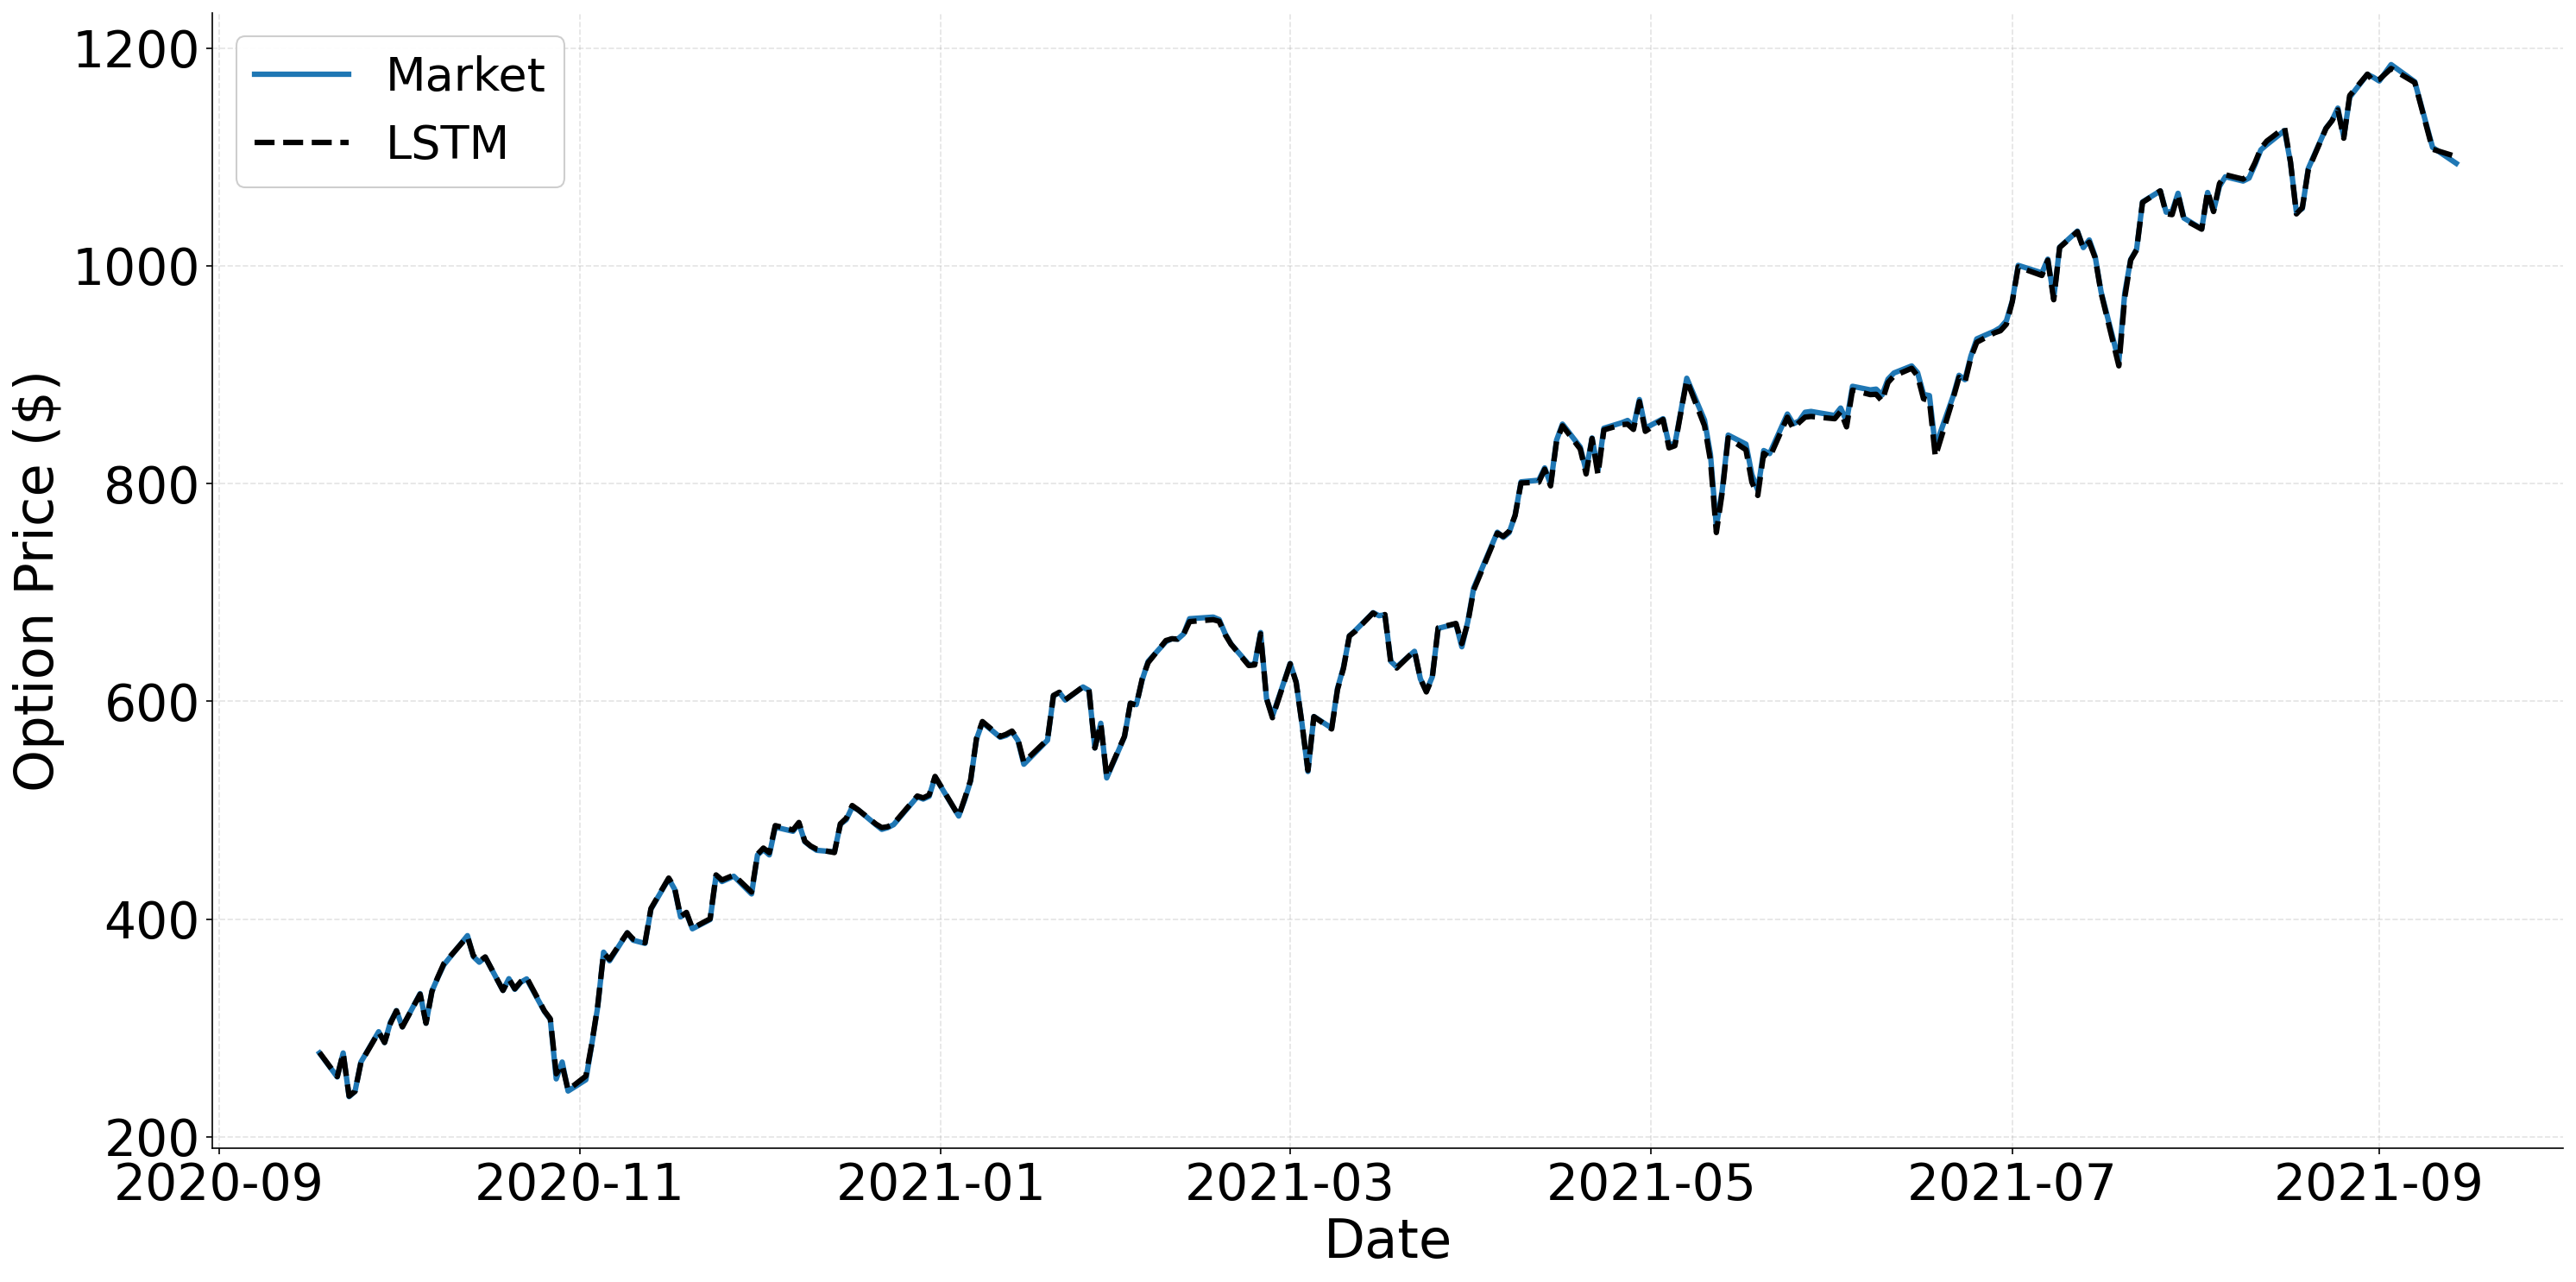

Saved PNG to: C:\Users\samib\OneDrive - Imperial College London\Imperial\Education\Year 4\Masters Project\Code\MastersProject\Results\long option\market_vs_lstm_long_option.png


In [40]:

# ------------------------------------------------------------------
# Market vs ML model plot (ATM, short-dated test option)
# ------------------------------------------------------------------
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ---- change these four for each model ----
MODEL_NAME_PRETTY = "LSTM"
MODEL_COLOUR      = "#000000"       # goldenrod
PRED              = mid_pred_test  # test predictions from the cell above
FILE_TAG          = "lstm"

print(PRED)

save_dir = Path(r"C:\Users\samib\OneDrive - Imperial College London\Imperial\Education\Year 4\Masters Project\Code\MastersProject\Results\long option")
save_dir.mkdir(parents=True, exist_ok=True)





plot_df = test_df.copy()
plot_df["date"] = pd.to_datetime(plot_df["date"])
plot_df = plot_df.sort_values("date").reset_index(drop=True)

# Trim market dataframe to match LSTM prediction length
plot_df = plot_df.iloc[-len(PRED):].copy().reset_index(drop=True)

# Now this works because both are length 52
plot_df["pred"] = pd.Series(PRED).values

fig, ax = plt.subplots(figsize=(20, 10), dpi=150)

ax.plot(plot_df["date"], plot_df["mid"],
        linewidth=3, label="Market")
ax.plot(plot_df["date"], plot_df["pred"],
        linewidth=3, linestyle="--",
        color=MODEL_COLOUR, label=MODEL_NAME_PRETTY)

ax.set_xlabel("Date", fontsize=30)
ax.set_ylabel("Option Price ($)", fontsize=30)
ax.grid(True, which="major", linestyle="--", alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=28)

leg = ax.legend(frameon=True, fontsize=26, loc="best")
leg.get_frame().set_alpha(0.95)

plt.tight_layout()

png_path = save_dir / f"market_vs_{FILE_TAG}_long_option.png"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved PNG to: {png_path}")


[186.0742323  209.11407571 205.40257071 215.32294258 196.60780717
 222.9184121  233.21302093 223.48715364 223.50632246 213.80787434
 192.35432828 153.72576163 190.27090987 211.06692333 216.64620314
 251.62881148 259.590133   246.42861007 241.53396282 254.60353547
 234.84276823 229.17416805 255.22305061 236.27945992 256.75491224
 259.2803849  254.9213824  258.45824596 265.75603403 275.89538567
 281.61362766 292.19594864 265.93743825 230.11045903 234.37886443
 259.33340761 289.73858755 295.59309836 303.78126372 281.70101173
 314.90224438 332.19959403 326.25078512 326.86873259 339.32292789
 337.57202772 322.78172709 316.58367167 296.52775904 263.67436268
 271.65755747 246.01128666 282.43249332 275.7765392 ]


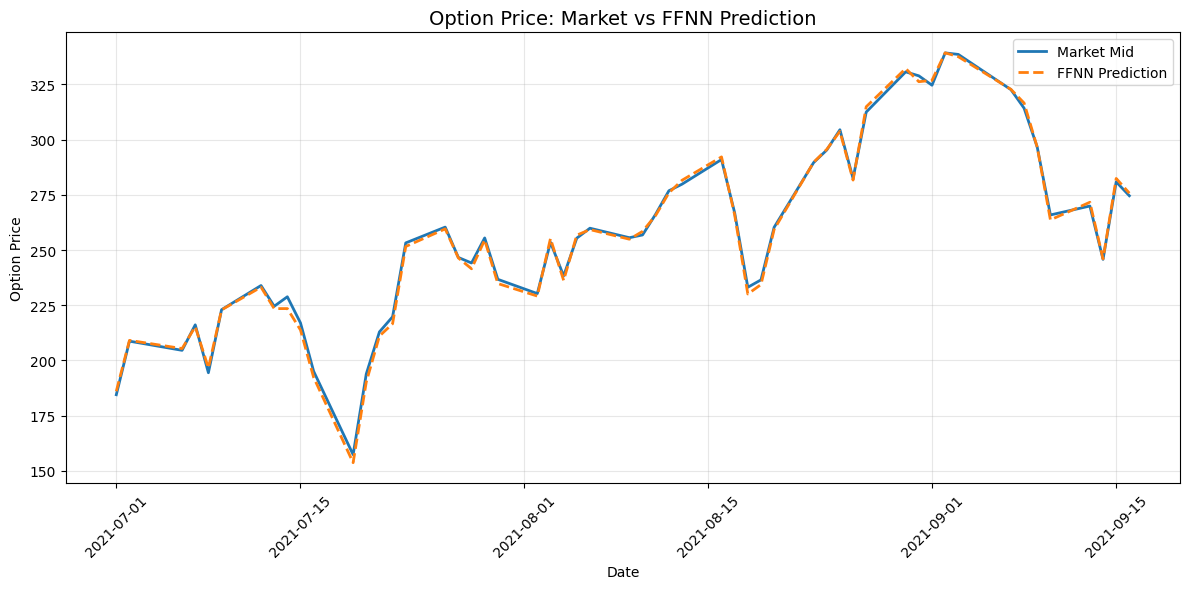

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print(mid_pred)

fig, ax = plt.subplots(figsize=(12,6))

ax.plot(test_df["date"], test_df["mid"], 
        label="Market Mid", linewidth=2)

ax.plot(test_df["date"], mid_pred, 
        label="FFNN Prediction", linewidth=2, linestyle="--")

ax.set_title("Option Price: Market vs FFNN Prediction", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Option Price")

ax.legend()
ax.grid(True, alpha=0.3)

# Better date formatting
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# import tensorflow as tf
# from tensorflow.keras import Sequential
# from tensorflow.keras.layers import LSTM, Dense, BatchNormalization
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
# from sklearn.metrics import mean_squared_error, mean_absolute_error
# import numpy as np

# # Assumes already built:
# # X_train_seq_s, y_train_seq
# # X_val_seq_s,   y_val_seq
# # X_test_seq_s,  y_test_seq
# # bs_test_seq,   mid_test_seq

# # ----------------------------
# # Paper-style hyperparams (from their Table 2)
# # ----------------------------
# LR = 0.002595
# WEIGHT_DECAY = 0.000333
# BATCH_SIZE = 4096
# BN_MOMENTUM = 0.262121
# PATIENCE = 20

# # ----------------------------
# # Model: 5 LSTM layers + BN after each (as in paper)
# # ----------------------------
# model = Sequential([
#     LSTM(64, return_sequences=True, input_shape=(X_train_seq_s.shape[1], X_train_seq_s.shape[2])),
#     BatchNormalization(momentum=BN_MOMENTUM),

#     LSTM(64, return_sequences=True),
#     BatchNormalization(momentum=BN_MOMENTUM),

#     LSTM(64, return_sequences=True),
#     BatchNormalization(momentum=BN_MOMENTUM),

#     LSTM(64, return_sequences=True),
#     BatchNormalization(momentum=BN_MOMENTUM),

#     LSTM(64, return_sequences=False),
#     BatchNormalization(momentum=BN_MOMENTUM),

#     # Dense head (paper describes Dense -> output)
#     Dense(32, activation="relu"),
#     Dense(1)
# ])

# # AdamW (paper uses AdamW + weight decay)
# optimizer = tf.keras.optimizers.AdamW(learning_rate=LR, weight_decay=WEIGHT_DECAY, clipnorm=1.0)

# model.compile(
#     optimizer=optimizer,
#     loss="mse",          # paper optimizes MSE
#     metrics=["mae"]
# )

# # ----------------------------
# # Callbacks: early stop + checkpoint best + optional LR schedule
# # ----------------------------
# ckpt = ModelCheckpoint(
#     filepath="best_lstm.keras",
#     monitor="val_loss",
#     save_best_only=True,
#     mode="min",
#     verbose=1
# )

# early_stop = EarlyStopping(
#     monitor="val_loss",
#     patience=PATIENCE,
#     mode="min",
#     restore_best_weights=True
# )

# reduce_lr = ReduceLROnPlateau(
#     monitor="val_loss",
#     factor=0.5,
#     patience=5,
#     min_lr=1e-6,
#     mode="min",
#     verbose=1
# )

# history = model.fit(
#     X_train_seq_s, y_train_seq,
#     validation_data=(X_val_seq_s, y_val_seq),
#     epochs=300,
#     batch_size=BATCH_SIZE,
#     callbacks=[ckpt, early_stop, reduce_lr],
#     verbose=1
# )

# # ----------------------------
# # Evaluate on TEST (residual -> mid)
# # ----------------------------
# yhat_res_test = model.predict(X_test_seq_s).ravel()

# mid_pred = bs_test_seq + yhat_res_test
# mid_true = mid_test_seq

# mse_test  = mean_squared_error(mid_true, mid_pred)
# rmse_test = np.sqrt(mse_test)
# mae_test  = mean_absolute_error(mid_true, mid_pred)

# print("LSTM Test MSE  (MID PRICE):", mse_test)
# print("LSTM Test RMSE (MID PRICE):", rmse_test)
# print("LSTM Test MAE  (MID PRICE):", mae_test)

In [29]:
# ============================================================
# CELL A (REVISED): XGBoost using SAME splits + includes bs_price
# ============================================================

import numpy as np
from xgboost import XGBRegressor

# ----------------------------
# 0) XGBoost feature set
#    Use your existing FEATURES + add bs_price explicitly
# ----------------------------
XGB_FEATURES = FEATURES + ["bs_price"]

# ----------------------------
# 1) Build X/y from the SAME dataframes you already created
# ----------------------------
X_train_xgb = train_sub_df[XGB_FEATURES].copy()
y_train_xgb = train_sub_df["mid"].values

X_val_xgb   = val_df[XGB_FEATURES].copy()
y_val_xgb   = val_df["mid"].values

X_test_xgb  = test_df[XGB_FEATURES].copy()
y_test_xgb  = test_df["mid"].values

print("XGB train features preview:")
display(X_train_xgb.head())

# ----------------------------
# 2) Drop any non-finite rows (XGB can't handle NaN/inf)
# ----------------------------
def _finite_rows(dfX, y):
    m = np.isfinite(dfX.values).all(axis=1) & np.isfinite(y)
    return dfX.loc[m].copy(), y[m], m

X_train_xgb, y_train_xgb, m_tr = _finite_rows(X_train_xgb, y_train_xgb)
X_val_xgb,   y_val_xgb,   m_va = _finite_rows(X_val_xgb,   y_val_xgb)
X_test_xgb,  y_test_xgb,  m_te = _finite_rows(X_test_xgb,  y_test_xgb)

print("XGB shapes:", X_train_xgb.shape, X_val_xgb.shape, X_test_xgb.shape)

# ----------------------------
# 3) XGBoost model (your params)
# ----------------------------
xgb_model = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=7,
    reg_alpha=0,
    reg_lambda=1.0,
    gamma=0.0,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=21,
    n_jobs=-1
)

print("Training XGBoost (direct mid, with bs_price feature)...")
xgb_model.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_val_xgb, y_val_xgb)],
    verbose=False
)

mid_pred_xgb = xgb_model.predict(X_test_xgb)

print("XGBoost done.")


XGB train features preview:


,S,K,T,log_moneyness,sigma,r 3 Mo,bs_price
16604739,3768.5,3090.0,0.213699,0.198506,0.2857,0.0004,691.841306
13843746,3251.8,2830.0,0.336986,0.138932,0.2446,0.0013,460.139436
15052614,3271.0,3405.0,0.013699,-0.040149,0.4028,0.0010,17.257973
13603707,3009.1,2240.0,0.306849,0.295165,0.3473,0.0014,783.476498
17170963,4185.5,3110.0,0.095890,0.297003,0.1625,0.0002,1075.559643


XGB shapes: (160000, 7) (40000, 7) (54, 7)
Training XGBoost (direct mid, with bs_price feature)...
XGBoost done.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

=== Test Metrics (MID Price) ===
XGBoost (direct)   RMSE=2.7887 | MAE=2.2371 | MSE=7.7769
FFNN (BS+resid)    RMSE=1.8520 | MAE=1.5008 | MSE=3.4300


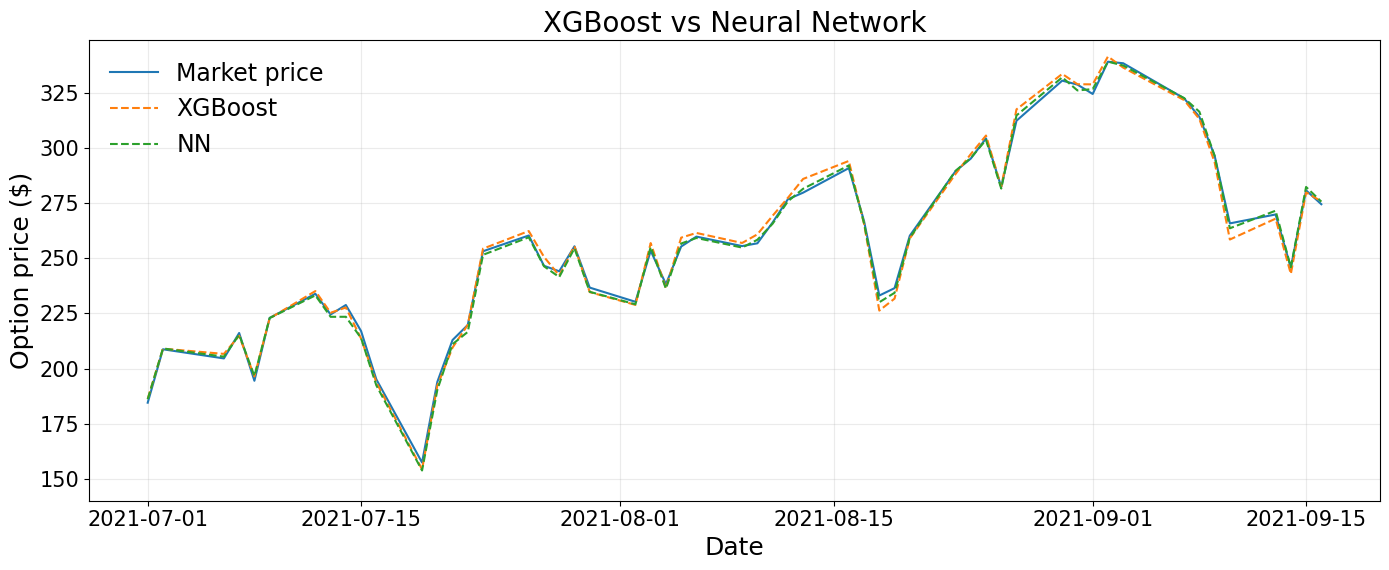

In [32]:
# ============================================================
# Compare: Market vs XGBoost vs FFNN (poster-ready)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ----------------------------
# 1) FFNN prediction (residual -> mid)
# ----------------------------
# Your FFNN uses scaled inputs X_test_s corresponding to test_df[FEATURES]
# If you dropped any rows from test_df for XGB, we need to align.
ffnn_res_pred_all = model.predict(X_test_s).ravel()
mid_pred_ffnn_all = test_df["bs_price"].values + ffnn_res_pred_all
mid_true_all      = test_df["mid"].values

# ----------------------------
# 2) Align arrays for fair comparison
#    XGB uses the finite mask m_te built in Cell A
# ----------------------------
# If you ran Cell A, m_te exists and indicates which test rows XGB used.
try:
    mid_true = mid_true_all[m_te]
    mid_pred_ffnn = mid_pred_ffnn_all[m_te]
except NameError:
    # fallback: assume no mask was created
    mid_true = mid_true_all
    mid_pred_ffnn = mid_pred_ffnn_all

# XGB outputs already correspond to the filtered test set (y_test_xgb / X_test_xgb)
mid_pred_xgb_aligned = mid_pred_xgb

# ----------------------------
# 3) Metrics
# ----------------------------
def _metrics(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name:<18} RMSE={rmse:.4f} | MAE={mae:.4f} | MSE={mse:.4f}")
    return rmse, mae, mse

print("\n=== Test Metrics (MID Price) ===")
_ = _metrics(mid_true, mid_pred_xgb_aligned, "XGBoost (direct)")
_ = _metrics(mid_true, mid_pred_ffnn,        "FFNN (BS+resid)")

# ----------------------------
# 4) Poster-ready TIME SERIES plot (like BS vs Heston)
# ----------------------------

# Ensure we have aligned dates too
try:
    dates_all = pd.to_datetime(test_df["date"]).values
    dates = dates_all[m_te]
except NameError:
    dates = pd.to_datetime(test_df["date"]).values

# Sort by date (NOT by price)
order = np.argsort(dates)

plt.figure(figsize=(14, 5.8))

plt.plot(dates[order], mid_true[order], label="Market price", linewidth=1.5)
plt.plot(dates[order], mid_pred_xgb_aligned[order], label="XGBoost", linewidth=1.5, linestyle="--")
plt.plot(dates[order], mid_pred_ffnn[order], label="NN", linewidth=1.5, linestyle="--")

plt.title("XGBoost vs Neural Network", fontsize=20)
plt.xlabel("Date", fontsize=18)
plt.ylabel("Option price ($)", fontsize=18)
plt.tick_params(axis="both", which="major", labelsize=15)

plt.grid(True, alpha=0.25)
plt.legend(frameon=False, fontsize=17, loc="best")
plt.ylim(140, 349)
plt.tight_layout()
plt.savefig("xgb_vs_ffnn_timeseries.png", dpi=300)
plt.show()

